# 03 — Population / land-use demand generation and quantised state-space dependence

## What this notebook is for

Two halves that only make sense together.

**Generation.** Build a long-horizon demand process whose causal chain is explicit:

$$ d_j(t) = \underbrace{P_j(t)}_{\text{population}} \cdot \underbrace{q(\text{income}_j(t))}_{\text{L/person/day}} \cdot \sum_c \underbrace{w_{jc}(t)}_{\text{land-use mix}} \cdot \underbrace{\text{shape}_c(t)}_{\text{rhythm}} \cdot \text{seasonal}(t) \cdot \text{noise}(t) $$

Population is the state variable; pressure is an **outcome**. This is a deliberate departure
from scaling a global demand multiplier until pressure hits its floor, which redistributes
consumption to sit exactly on the limit and so bakes the answer into the setup.

**Inference.** Quantise the resulting series into a small alphabet, estimate symbolic Markov
chains, and measure dependence from the *probabilities of change* — occupancy for regimes,
mutual information for instantaneous coupling, transfer entropy for directed coupling. Then
score that observational estimate against the **interventional** ground truth from notebook
02, which is the only thing that makes a causal claim on this system falsifiable.

## Definitions

| symbol | meaning |
|---|---|
| $P_j$ | population equivalents at junction $j$ (commerce/industry enter as PE, so one unit) |
| $q$ | per-capita demand, L/person/day, scaled by income band |
| $w_{jc}$ | land-use mix on the simplex; changes the **shape** of demand |
| $k_1, k_2$ | daily and hourly peak factors (max-day/mean-day, max-hour/mean-hour) |
| $P_\max$ | population ceiling from hydraulic capacity, **after** peak factors |
| $X^{(K)}_j(t)$ | node $j$'s deseasonalised residual quantised to $K$ symbols |
| $\mathrm{MI}(i,j)$ | lag-0 mutual information, bits — undirected instantaneous coupling |
| $\mathrm{TE}_{i\to j}(L)$ | $I(X_j(t{+}1); X_i(t{+}1{-}L) \mid X_j(t))$, bits — directed, surrogate-corrected |

## The identifiability constraint, stated up front

Population and per-capita demand **multiply**. From water data alone, a 20% population rise
and a 20% income-driven rise in consumption are indistinguishable: same level, same shape.
Land use is different, because it changes the shape, and shape is identifiable from level.

- land use $\Rightarrow$ **recoverable** by an observational estimator
- population $\times$ income $\Rightarrow$ recoverable only as a **product**

`ScenarioConfig.assert_identifiable` refuses to build a scenario whose shape drift and level
drift overlap in time on shared districts, because the ground truth would then not be
recoverable and any recovery claim would be unfalsifiable. A `connections` column is carried
alongside demand throughout: meter counts are the extra observable that *would* separate
population from income in a real utility, and it cannot be retrofitted once runs exist.

## Two facts inherited from notebook 02 that constrain everything here

1. **Instantaneous hydraulic coupling is undirected** — the demand-to-pressure Jacobian is
   symmetric, verified to $10^{-5}$–$10^{-4}$ on valveless networks. So the interventional
   map validates *whether* a pair is coupled, never the direction of a TE edge.
2. **Lag requires control-mediated tank cycling.** Measured: a tankless network shows
   exactly zero lag; a network with tanks but *no controls* also shows zero lag; only tanks
   **plus** controls produce non-zero propagation lag. Transfer entropy at lag $\ge 1$ is
   therefore expected to be null on networks lacking that mechanism, and that null is a
   correct result rather than a failure to detect.


In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wntr

sys.path.insert(0, str(Path.cwd()))
import wdn_demand as wd
import wdn_dependency as dep
import wdn_statespace as ss

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 200)
warnings.simplefilter('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})


def find_network_dir(candidates=('../../data/00_networks', 'nets', 'networks', '.')):
    """Locate the corpus without hardcoding a path, so the notebook is portable."""
    for c in candidates:
        p = Path(c)
        if p.is_dir() and any(p.glob('*.inp')):
            return p
    raise FileNotFoundError('no .inp files found under any of %s' % (candidates,))


NETWORK_DIR = find_network_dir()
OUT_DIR = Path('data/08_reporting/statespace')
OUT_DIR.mkdir(parents=True, exist_ok=True)
GT_DIR = Path('data/08_reporting/dependency/ground_truth')

print('%d networks in %s' % (len(list(NETWORK_DIR.glob('*.inp'))), NETWORK_DIR))
print('wntr', wntr.__version__)


26 networks in ..\..\data\00_networks
wntr 1.3.2


## 0. Configuration

Everything that changes a result lives here. Two settings deserve comment.

`N_CHUNKS` sets the horizon in 28-day blocks. 28 days is a multiple of 7, so the weekly
profile stays phase-aligned across chunk boundaries and no boundary handling is needed.
The default is a working horizon; **44 chunks is 40 months**, the target for a full run.

`TE_NODES` caps the node set for the pairwise information measures, whose cost is
$O(n^2 \cdot |\text{lags}| \cdot n_\text{surrogates})$. Subsetting is a computational
choice, not a statistical one — but the *same* node set must be used for the estimator and
for the ground truth, or the comparison is meaningless. That constraint is enforced below.

In [3]:
# ---- network selection -------------------------------------------------
# Chosen to have the lag mechanism (tanks AND controls), since a network without
# it cannot produce lagged dependence and would make the TE half of this
# notebook vacuous. A tankless control network is analysed alongside it.
def pick_networks(network_dir):
    """Rank candidates by whether they can carry lag, then by simplicity."""
    rows = []
    for f in sorted(network_dir.glob('*.inp')):
        wn = wntr.network.WaterNetworkModel(str(f))
        cons = dep.consumer_nodes(wn)
        rows.append({'network': f.stem, 'n_consumers': len(cons),
                     'tanks': len(wn.tank_name_list),
                     'pumps': len(wn.pump_name_list),
                     'valves': len(wn.valve_name_list),
                     'controls': len(wn.control_name_list),
                     'demand_lps': sum(dep.base_demand_of(wn, j) for j in cons)
                     * dep.LPS_PER_M3S
                     * float(wn.options.hydraulic.demand_multiplier or 1.0)})
    c = pd.DataFrame(rows).set_index('network')
    c['has_lag_mechanism'] = (c.tanks > 0) & (c.controls > 0)
    c['complexity'] = c.tanks + c.pumps + c.valves
    return c


CANDIDATES = pick_networks(NETWORK_DIR)
lagged = CANDIDATES[CANDIDATES.has_lag_mechanism & (CANDIDATES.n_consumers > 0)]
flat = CANDIDATES[(~CANDIDATES.has_lag_mechanism) & (CANDIDATES.n_consumers > 0)]
NETWORK = lagged.nsmallest(1, 'complexity').index[0]
NETWORK = 'D_Town'
CONTROL_NETWORK = flat.nsmallest(1, 'complexity').index[0] if len(flat) else None
print('primary (lag-capable):', NETWORK)
print('negative control (no lag mechanism):', CONTROL_NETWORK)
display(CANDIDATES.loc[[n for n in (NETWORK, CONTROL_NETWORK) if n]])

# ---- generation --------------------------------------------------------
SHAPES = wd.ShapeParams()
DEMAND_MODEL = wd.DemandModelConfig()          # per-capita, income, k1/k2, PE
ASSIGN = wd.AssignmentConfig(n_districts=5, seed=20)

N_CHUNKS = 18                                   # 28-day chunks; 44 == 40 months
DRIFT_START = N_CHUNKS // 2
DRIFT_TRANSITION = 3

SCENARIO = wd.ScenarioConfig(
    n_chunks=N_CHUNKS, chunk_days=28, timestep_s=3600,
    initial_capacity_fraction=0.40,             # conservative start, room to grow
    logistic_rate_per_chunk=0.05,
    district_rate_spread=0.5,                   # heterogeneous -> non-IID clients
    seasonal=True,
    noise_sigma_district=0.06, noise_sigma_common=0.03, noise_ar1=0.4,
    seed=20,
    drifts=(
        # shape drift only: land use converts in two districts. No level drift
        # overlaps it, so the ground truth stays recoverable.
        wd.DriftSpec('landuse_conversion', districts=(0, 2),
                     start_chunk=DRIFT_START, transition_chunks=DRIFT_TRANSITION,
                     magnitude=0.65, from_category='residential',
                     to_category='industrial'),
    ),
)

RUN = wd.RunConfig(demand_model='PDD',          # unserved demand is measurable
                   required_pressure_m=15.0, pressure_floor_m=15.0,
                   verbose=True)

# ---- inference ---------------------------------------------------------
SS = ss.StateSpaceConfig(n_symbols=3, mode='level', baseline_fraction=0.30,
                         deseasonalise=True, detrend_window=14 * 24,
                         lags=(1, 2, 3, 6),
                         n_surrogates=40, surrogate_block=24,
                         significance_quantile=0.95, seed=20)
TE_NODES = 45          # pairwise cost is quadratic in this
print('\nhorizon: %d chunks x %d days = %.1f months, %d steps'
      % (SCENARIO.n_chunks, SCENARIO.chunk_days, SCENARIO.horizon_months,
         SCENARIO.n_chunks * SCENARIO.steps_per_chunk))


primary (lag-capable): D_Town
negative control (no lag mechanism): Balerma


,n_consumers,tanks,pumps,valves,controls,demand_lps,has_lag_mechanism,complexity
network,,,,,,,,
D_Town,348,7,11,5,24,422.267565,True,23
Balerma,442,0,0,0,0,1103.895000,False,0



horizon: 18 chunks x 28 days = 16.6 months, 12096 steps


## 1. Land-use shapes — sanity checks first

Shapes are **generated from interpretable parameters**, not pasted as arrays, so what is
being claimed is visible and changeable. Three checks that can fail:

1. Every shape has mean exactly 1. This is the invariant that keeps all volume information
   in the base demand, so a land-use change alters rhythm and nothing else.
2. Peak factors are physically plausible (residential bimodal and peakier than industrial).
3. A concatenated multi-day profile is also mean 1, so weekly modulation redistributes
   within a chunk instead of changing its volume.

In [4]:
shape_frame = SHAPES.as_frame()
checks = pd.DataFrame({
    'mean': shape_frame[list(wd.CATEGORIES)].mean(),
    'peak_factor': shape_frame[list(wd.CATEGORIES)].max(),
    'trough': shape_frame[list(wd.CATEGORIES)].min(),
})
checks['mean_is_one'] = np.isclose(checks['mean'], 1.0, atol=1e-9)
display(checks.round(4))

prof_checks = []
for c in wd.CATEGORIES:
    p = SHAPES.profile(c, SCENARIO.chunk_days, SCENARIO.start_dow)
    prof_checks.append({'category': c, 'len': len(p), 'mean': p.mean(),
                        'peak_factor': p.max()})
prof = pd.DataFrame(prof_checks)
prof['mean_is_one'] = np.isclose(prof['mean'], 1.0, atol=1e-9)
display(prof.round(6))
assert checks.mean_is_one.all() and prof.mean_is_one.all(), \
    'shape normalisation broken: volume would leak into the rhythm'
print('PASS: shapes carry rhythm only; all volume lives in the base demand')


,mean,peak_factor,trough,mean_is_one
residential,1.0,1.8910,0.4084,True
commercial,1.0,1.9739,0.2705,True
industrial,1.0,1.1135,0.9381,True


,category,len,mean,peak_factor,mean_is_one
0,residential,672,1.0,2.044839,True
1,commercial,672,1.0,2.356380,True
2,industrial,672,1.0,1.172058,True


PASS: shapes carry rhythm only; all volume lives in the base demand


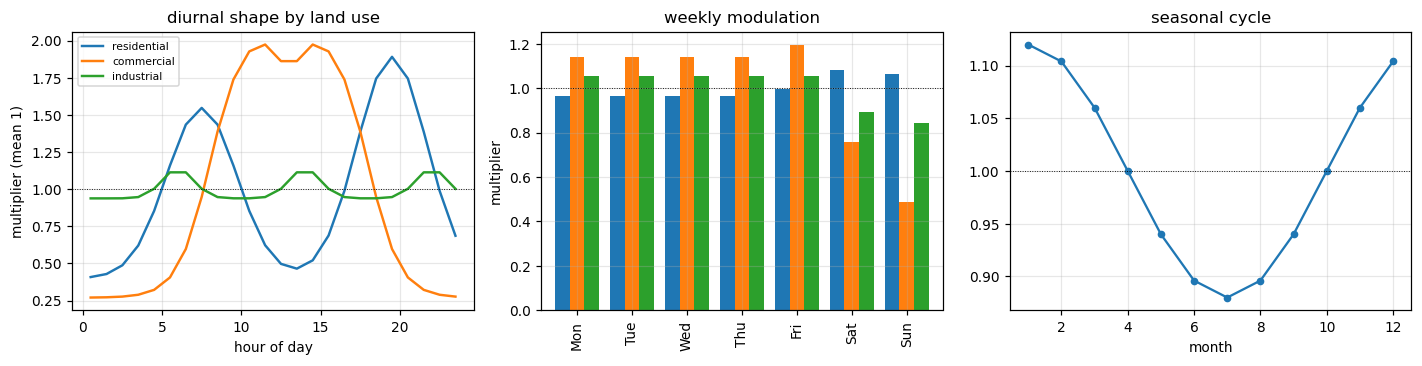

,mix,system_peak_factor
0,all residential,1.8910
1,mixed 70/22/8,1.5308
2,shifted 35/55/10,1.4556


A conversion toward commercial lowers the system peak factor by desynchronising peaks, so demand can grow without the peak growing proportionally. Any capacity check must use the realised peak, not a nominal one.


In [5]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
for c in wd.CATEGORIES:
    ax[0].plot(shape_frame.hour, shape_frame[c], label=c, lw=1.6)
ax[0].axhline(1.0, color='k', lw=0.6, ls=':')
ax[0].set_xlabel('hour of day')
ax[0].set_ylabel('multiplier (mean 1)')
ax[0].set_title('diurnal shape by land use')
ax[0].legend(fontsize=7)

dows = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
w = pd.DataFrame({c: SHAPES.weekly(c) for c in wd.CATEGORIES}, index=dows)
w.plot(kind='bar', ax=ax[1], width=0.8, legend=False)
ax[1].axhline(1.0, color='k', lw=0.6, ls=':')
ax[1].set_title('weekly modulation')
ax[1].set_ylabel('multiplier')

m = np.arange(12)
ax[2].plot(m + 1, SHAPES.seasonal(m), marker='o', ms=4)
ax[2].axhline(1.0, color='k', lw=0.6, ls=':')
ax[2].set_xlabel('month')
ax[2].set_title('seasonal cycle')
for a in ax:
    a.grid(alpha=0.3)
fig.tight_layout()
plt.show()

# A land-use change alters the SYSTEM peak factor even at fixed volume, because
# residential and commercial peaks are not synchronous. This desynchronisation is
# the mechanism a shape drift acts through, so it is worth seeing directly.
mixes = {'all residential': (1, 0, 0), 'mixed 70/22/8': (0.70, 0.22, 0.08),
         'shifted 35/55/10': (0.35, 0.55, 0.10)}
rows = []
for label, wts in mixes.items():
    agg = sum(wt * SHAPES.diurnal(c) for wt, c in zip(wts, wd.CATEGORIES))
    rows.append({'mix': label, 'system_peak_factor': agg.max() / agg.mean()})
display(pd.DataFrame(rows).round(4))
print('A conversion toward commercial lowers the system peak factor by '
      'desynchronising peaks, so demand can grow without the peak growing '
      'proportionally. Any capacity check must use the realised peak, not a nominal one.')


## 2. Assignment: districts, land use, income

Explicitly a **heuristic**, and explicitly swappable — `assign_landuse(..., classifier=fn)`
accepts a callable, so real land-use or income layers replace it without touching anything
downstream. The heuristic uses only quantities a utility plausibly has: served area (half
the length of incident pipes), existing base demand, and spatial position.

Districts here come from spatial k-means. Notebook 02 also derives districts from hydraulic
coupling; the two are compared at the end, since a federated partition that ignores
hydraulics is a different object from one that follows it.

In [7]:
wn = wntr.network.WaterNetworkModel(str(NETWORK_DIR / (NETWORK + '.inp')))
consumers = dep.consumer_nodes(wn)
assignment = wd.assign_landuse(wn, consumers, ASSIGN)
assignment.to_csv(OUT_DIR / ('assignment_%s.csv' % NETWORK))

print('%s: %d consumers, %d districts' % (NETWORK, len(assignment),
                                          assignment.district.nunique()))
display(assignment.groupby('district')[list(wd.CATEGORIES)].mean().round(3))
display(assignment.groupby('district').agg(
    n=('income', 'size'), pop_share=('pop_share', 'sum'),
    served_km=('served_length_m', lambda s: s.sum() / 1000)).round(4))

# sanity: mixes lie on the simplex, population shares sum to 1
simplex_ok = np.allclose(assignment[list(wd.CATEGORIES)].sum(axis=1), 1.0)
share_ok = np.isclose(assignment.pop_share.sum(), 1.0)
print('mixes on the simplex:', simplex_ok, '| pop_share sums to 1:', share_ok)
assert simplex_ok and share_ok


D_Town: 348 consumers, 5 districts


,residential,commercial,industrial
district,,,
0,0.515,0.462,0.023
1,0.836,0.144,0.020
2,0.701,0.282,0.017
3,0.821,0.116,0.063
4,0.921,0.022,0.057


,n,pop_share,served_km
district,,,
0,68,0.1639,9.1319
1,54,0.1915,10.6690
2,114,0.2845,15.8508
3,60,0.1948,10.8528
4,52,0.1653,9.2115


mixes on the simplex: True | pop_share sums to 1: True


## 3. Capacity in population terms

The peak factors are the whole point. A capacity in L/s taken from a constant-demand sweep
is a **mean** flow the network can sustain, but a real system must survive the peak hour of
the peak day. So the sustainable mean is capacity divided by $k_1 k_2$, and ignoring that
overstates the population a network can serve by ~80% at the default factors.

Capacity is measured here directly rather than imported, so this notebook stands alone: a
bisection on a global multiplier under **constant demand and steady state**, with tanks at
their **minimum** level. Minimum is the defensible choice for a long horizon — capacity at
the initial (typically full) level is borrowed from storage rather than supplied by the
network.

In [8]:
def measure_capacity_lps(wn, floor_m=15.0, tank_level='min',
                         lo=0.05, hi=25.0, tol=0.02, max_iter=16):
    """Largest constant demand the network serves at or above the pressure floor.

    Steady state (no tank drift), constant demand (lambda is the only knob), and
    consumer junctions only -- sub-atmospheric pressure on a pump-suction dummy
    node is modelling scaffolding, not unserved demand.
    """
    import copy
    w = copy.deepcopy(wn)
    m0 = float(w.options.hydraulic.demand_multiplier or 1.0)
    for n in w.junction_name_list:
        for ts in w.get_node(n).demand_timeseries_list:
            if ts.base_value:
                ts.base_value = float(ts.base_value) * m0
            ts.pattern_name = None                      # constant demand
    w.options.hydraulic.demand_multiplier = 1.0
    w.options.time.duration = 0                         # steady state
    if tank_level == 'min':
        for t in w.tank_name_list:
            tk = w.get_node(t)
            tk.init_level = float(tk.min_level)
    cons = set(dep.consumer_nodes(w))
    base = sum(dep.base_demand_of(w, j) for j in cons) * dep.LPS_PER_M3S

    def feasible(lam):
        w.options.hydraulic.demand_multiplier = float(lam)
        try:
            r = dep.solve(w)
        except Exception:
            return False, np.nan
        cols = [c for c in r.node['pressure'].columns if c in cons]
        p = r.node['pressure'][cols].to_numpy()
        if not p.size or np.nanmax(np.abs(p)) > 1000.0:   # non-physical
            return False, np.nan
        return bool(np.nanmin(p) >= floor_m), float(np.nanmin(p))

    ok_lo, p_lo = feasible(lo)
    if not ok_lo:
        return {'capacity_lps': np.nan, 'lambda_star': np.nan,
                'base_demand_lps': base, 'status': 'infeasible at lambda=%g '
                '(pressure %.1f m) -- defects independent of demand' % (lo, p_lo)}
    ok_hi, _ = feasible(hi)
    if ok_hi:
        return {'capacity_lps': base * hi, 'lambda_star': hi,
                'base_demand_lps': base,
                'status': 'still feasible at lambda=%g; raise the bracket' % hi}
    a, b, n = lo, hi, 2
    while (b - a) / max(a, 1e-9) > tol and n < max_iter:
        mid = 0.5 * (a + b)
        ok, _ = feasible(mid)
        a, b = (mid, b) if ok else (a, mid)
        n += 1
    return {'capacity_lps': base * a, 'lambda_star': a, 'base_demand_lps': base,
            'n_solves': n, 'status': 'bracketed'}


cap = measure_capacity_lps(wn, floor_m=RUN.pressure_floor_m, tank_level='min')
print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in cap.items()})

mix = assignment[list(wd.CATEGORIES)].mean().to_dict()
pop = wd.capacity_to_population(cap['capacity_lps'], DEMAND_MODEL,
                                income_band='medium', category_mix=mix)
display(pd.Series(pop).round(4).to_frame('value'))
P_MAX = pop['population_equivalent_capacity']
print('\nP_max = %.0f PE.  Starting population = %.0f PE (%.0f%% of capacity).'
      % (P_MAX, SCENARIO.initial_capacity_fraction * P_MAX,
         100 * SCENARIO.initial_capacity_fraction))
print('Peak factors cost a factor of %.2f: without them the ceiling would look '
      '%.0f PE.' % (pop['peak_factor'], P_MAX * pop['peak_factor']))


{'capacity_lps': 234.6028, 'lambda_star': 0.5556, 'base_demand_lps': 422.2676, 'n_solves': 14, 'status': 'bracketed'}


,value
capacity_lps,234.6028
peak_factor,1.8000
sustainable_mean_lps,130.3349
population_equivalent_capacity,64587.1329
pe_weighted_intensity,1.0897
per_capita_lps,0.0019



P_max = 64587 PE.  Starting population = 25835 PE (40% of capacity).
Peak factors cost a factor of 1.80: without them the ceiling would look 116257 PE.


## 4. Trajectory and whole-horizon validation

Growth is logistic and **heterogeneous across districts**, which is what makes the federated
clients genuinely non-IID rather than noisy copies.

Validating only the initial state is the trap: growth is monotone, so a scenario that starts
comfortably can end far past the network's limit and would waste the whole run before
failing. Every chunk's **realised** peak demand is checked against capacity before a single
hydraulic solve.

In [9]:
traj = wd.build_trajectory(assignment, P_MAX, SCENARIO, DEMAND_MODEL)
valid = wd.validate_trajectory(traj, SHAPES, SCENARIO, cap['capacity_lps'])
valid.to_csv(OUT_DIR / ('trajectory_validation_%s.csv' % NETWORK), index=False)

print('drifts:')
display(traj['drifts'])
print('district growth rates per chunk (heterogeneity -> non-IID clients):')
display(traj['growth_rates'].round(4).to_frame())
display(valid.round(3))
if valid.breach.any():
    print('BREACH in chunks %s: peak demand exceeds capacity. The scenario must be '
          'retuned (lower initial_capacity_fraction or logistic_rate_per_chunk) '
          'before running.' % valid.index[valid.breach].tolist())
else:
    print('PASS: peak-hour demand stays under capacity for the whole horizon '
          '(min headroom ratio %.2f).' % valid.headroom_ratio.min())


drifts:


,kind,districts,start_chunk,transition_chunks,magnitude,from_category,to_category
0,landuse_conversion,"[0, 2]",9,3,0.65,residential,industrial


district growth rates per chunk (heterogeneity -> non-IID clients):


,rate_per_chunk
0,0.0390
1,0.0481
2,0.0311
3,0.0511
4,0.0455


,chunk,mean_lps,peak_lps,population,peak_factor_realised,capacity_lps,headroom_ratio,breach
0,0,56.488,88.944,25834.853,1.575,234.603,2.638,False
1,1,57.860,91.143,26461.764,1.575,234.603,2.574,False
2,2,58.390,92.015,27092.671,1.576,234.603,2.550,False
3,3,57.380,90.460,27727.003,1.577,234.603,2.593,False
4,4,55.377,87.335,28364.175,1.577,234.603,2.686,False
5,5,53.228,83.977,29003.589,1.578,234.603,2.794,False
6,6,51.863,81.852,29644.638,1.578,234.603,2.866,False
7,7,52.037,82.153,30286.709,1.579,234.603,2.856,False
8,8,54.122,85.453,30929.182,1.579,234.603,2.745,False
9,9,58.105,91.479,31571.436,1.574,234.603,2.565,False


PASS: peak-hour demand stays under capacity for the whole horizon (min headroom ratio 1.95).


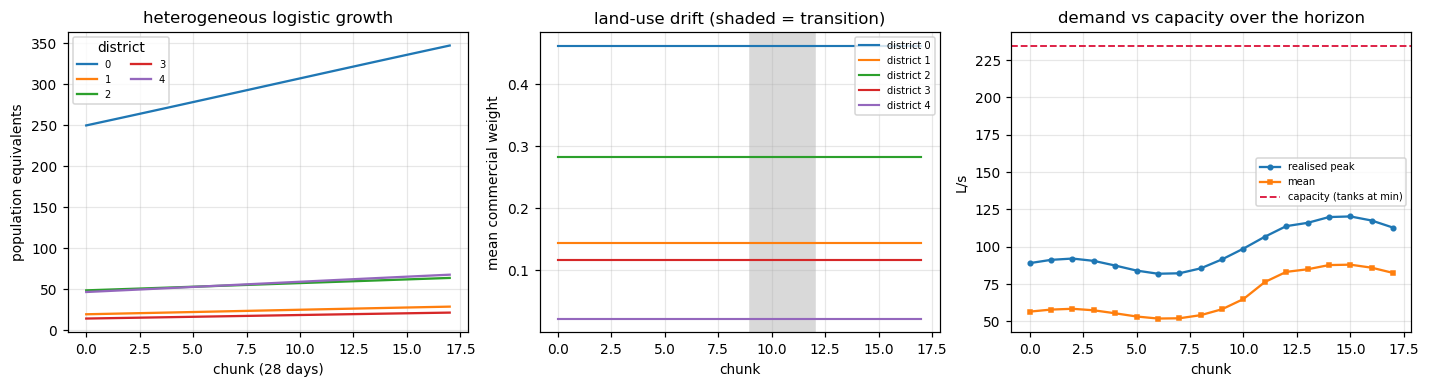

In [10]:
t = traj['trajectory']
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))

popd = t.groupby(['chunk', 'district']).population.first().unstack()
popd.plot(ax=ax[0], lw=1.5)
ax[0].set_ylabel('population equivalents')
ax[0].set_xlabel('chunk (28 days)')
ax[0].set_title('heterogeneous logistic growth')
ax[0].legend(title='district', fontsize=6.5, ncol=2)

mixt = (t.pivot_table(index=['chunk', 'district'], columns='category',
                      values='weight', aggfunc='mean')
         .reset_index())
for d, g in mixt.groupby('district'):
    ax[1].plot(g.chunk, g.commercial, lw=1.4, label='district %s' % d)
ax[1].axvspan(DRIFT_START, DRIFT_START + DRIFT_TRANSITION, color='0.85', zorder=0)
ax[1].set_xlabel('chunk')
ax[1].set_ylabel('mean commercial weight')
ax[1].set_title('land-use drift (shaded = transition)')
ax[1].legend(fontsize=6.5)

ax[2].plot(valid.chunk, valid.peak_lps, marker='o', ms=3, label='realised peak')
ax[2].plot(valid.chunk, valid.mean_lps, marker='s', ms=3, label='mean')
ax[2].axhline(cap['capacity_lps'], color='crimson', ls='--', lw=1.2,
              label='capacity (tanks at min)')
ax[2].set_xlabel('chunk')
ax[2].set_ylabel('L/s')
ax[2].set_title('demand vs capacity over the horizon')
ax[2].legend(fontsize=6.5)
for a in ax:
    a.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## 5. Chunked simulation

State handed across each boundary: **tank levels**, **pump status**, and the noise series
(generated once for the whole horizon, so it is continuous by construction). Weekly phase
needs no handling because `chunk_days` is a multiple of 7.

Controls are deliberately **not** adapted as demand grows. Real infrastructure lags demand,
so holding them fixed produces genuine progressive degradation — rising pump duty cycle,
then tanks failing to recover, then pressure decline. That is a real regime transition;
adapting the controls would erase the signal we are trying to observe.

A failing chunk does not abort the run: a horizon that dies at chunk 30 should still yield
30 usable chunks plus a diagnosis.

In [11]:
sim = wd.simulate_scenario(wn, traj, SHAPES, SCENARIO, RUN)
health = sim['health']
health.to_csv(OUT_DIR / ('health_%s.csv' % NETWORK), index=False)
print('\nsimulated %s in %.0fs -> pressure %s, demand %s'
      % (NETWORK, sim['seconds'], sim['pressure'].shape, sim['demand'].shape))
display(health.round(4))


    chunk 2/18  pmin=22.8m  unserved=0.000  2s
    chunk 4/18  pmin=23.1m  unserved=0.000  4s
    chunk 6/18  pmin=23.9m  unserved=0.000  6s
    chunk 8/18  pmin=23.6m  unserved=0.000  8s
    chunk 10/18  pmin=22.3m  unserved=0.000  10s
    chunk 12/18  pmin=21.9m  unserved=0.001  12s
    chunk 14/18  pmin=21.9m  unserved=0.002  16s
    chunk 16/18  pmin=22.7m  unserved=0.004  18s
    chunk 18/18  pmin=21.9m  unserved=0.004  20s

simulated D_Town in 20s -> pressure (12096, 348), demand (12096, 348)


,chunk,converged,error,n_steps,pressure_min_m,pressure_max_m,frac_below_floor,frac_negative,overpressure,expected_lps,delivered_lps,unserved_frac,population,tank_frac_at_min,tank_frac_at_max,tank_net_drift_m,pump_duty_cycle,pump_switches
0,0,True,,672,23.1226,110.6805,0.0,0.0,False,56.4884,56.4248,0.0011,25834.8531,0.0,0.0006,1.5983,0.1130,669
1,1,True,,672,22.8042,106.8566,0.0,0.0,False,57.8599,57.9091,0.0000,26461.7637,0.0,0.0009,-0.2231,0.1131,672
2,2,True,,672,23.3854,106.0506,0.0,0.0,False,58.3898,58.5938,0.0000,27092.6706,0.0,0.0004,0.7133,0.1142,678
3,3,True,,672,23.1004,106.9644,0.0,0.0,False,57.3800,57.3626,0.0003,27727.0027,0.0,0.0006,-0.9072,0.1117,668
4,4,True,,672,23.8145,107.5864,0.0,0.0,False,55.3767,55.2010,0.0032,28364.1745,0.0,0.0006,-0.1359,0.1059,647
5,5,True,,672,23.8523,107.2460,0.0,0.0,False,53.2281,53.3325,0.0000,29003.5887,0.0,0.0000,0.1161,0.1054,648
6,6,True,,672,23.8228,107.6628,0.0,0.0,False,51.8630,51.8807,0.0000,29644.6381,0.0,0.0004,0.3472,0.1015,636
7,7,True,,672,23.5976,108.5330,0.0,0.0,False,52.0369,52.3264,0.0000,30286.7086,0.0,0.0002,0.0517,0.1027,636
8,8,True,,672,22.8168,107.6891,0.0,0.0,False,54.1221,54.3751,0.0000,30929.1816,0.0,0.0004,-0.2805,0.1062,645
9,9,True,,672,22.2853,105.1589,0.0,0.0,False,58.1051,58.1112,0.0000,31571.4364,0.0,0.0011,0.3278,0.1111,661


### 5b. Simulation sanity checks

Four checks that can fail, on things a long chunked run can silently get wrong.

1. **Clock integrity** — uniform timestep, no gaps or duplicated steps at chunk boundaries.
   EPANET reports `duration/ts + 1` points, so a naive chunk length duplicates the first
   pattern step of every chunk.
2. **Mass balance** — delivered demand tracks expected demand. Under PDD a real shortfall is
   *supposed* to appear as unserved demand, so this check reads deviation as physics unless
   pressures are healthy.
3. **Tank continuity** — the level at the start of a chunk equals the level at the end of the
   previous one. This is the state handoff, and if it is broken every long-horizon result is
   an artifact of chunking.
4. **Regime activity** — pump switching actually occurs. With no switching there is no
   control-mediated tank cycling, hence no lag mechanism, hence nothing for transfer
   entropy to find.

In [12]:
P = sim['pressure']
cal = wd.build_time_index(SCENARIO, len(P))

# 1. clock integrity
dt = np.diff(P.index.to_numpy())
clock_ok = bool(np.all(dt == SCENARIO.timestep_s))
expected_steps = SCENARIO.n_chunks * SCENARIO.steps_per_chunk
print('1. clock: %d steps (expected %d), uniform dt=%s -> %s'
      % (len(P), expected_steps, clock_ok, 'PASS' if clock_ok
         and len(P) == expected_steps else 'CHECK'))

# 2. mass balance
mb = health[['chunk', 'expected_lps', 'delivered_lps', 'unserved_frac',
             'pressure_min_m']].copy()
mb['rel_error'] = (mb.delivered_lps - mb.expected_lps) / mb.expected_lps
worst = mb.rel_error.abs().max()
print('2. mass balance: worst relative deviation %.4f; max unserved %.4f; '
      'min pressure %.1f m -> %s'
      % (worst, mb.unserved_frac.max(), mb.pressure_min_m.min(),
         'PASS (deviation is unserved demand, not bookkeeping)'
         if mb.pressure_min_m.min() < RUN.pressure_floor_m or worst < 0.02
         else 'CHECK'))

# 3. tank continuity across chunk boundaries
TL = sim['tank_level']
if len(TL):
    spc = SCENARIO.steps_per_chunk
    jumps = []
    for k in range(1, SCENARIO.n_chunks):
        i_prev, i_next = k * spc - 1, k * spc
        if i_next < len(TL):
            jumps.append(np.abs(TL.iloc[i_next].to_numpy()
                                - TL.iloc[i_prev].to_numpy()).max())
    jumps = np.array(jumps)
    span = float((TL.max() - TL.min()).max())
    print('3. tank handoff: max boundary jump %.4f m (%.2f%% of level span %.2f m) -> %s'
          % (jumps.max(), 100 * jumps.max() / max(span, 1e-9), span,
             'PASS' if jumps.max() < 0.05 * max(span, 1e-9) else 'CHECK'))
else:
    print('3. tank handoff: no tanks in this network')

# 4. regime activity
if 'pump_switches' in health:
    print('4. regime activity: %d-%d pump switches per chunk, duty cycle %.2f-%.2f -> %s'
          % (health.pump_switches.min(), health.pump_switches.max(),
             health.pump_duty_cycle.min(), health.pump_duty_cycle.max(),
             'PASS (control-mediated cycling present)'
             if health.pump_switches.min() > 0 else
             'FAIL (no switching -> no lag mechanism)'))
else:
    print('4. regime activity: no pumps')


1. clock: 12096 steps (expected 12096), uniform dt=True -> PASS
2. mass balance: worst relative deviation 0.0059; max unserved 0.0053; min pressure 21.1 m -> PASS (deviation is unserved demand, not bookkeeping)
3. tank handoff: max boundary jump 0.0000 m (0.00% of level span 5.28 m) -> PASS
4. regime activity: 636-857 pump switches per chunk, duty cycle 0.10-0.18 -> PASS (control-mediated cycling present)


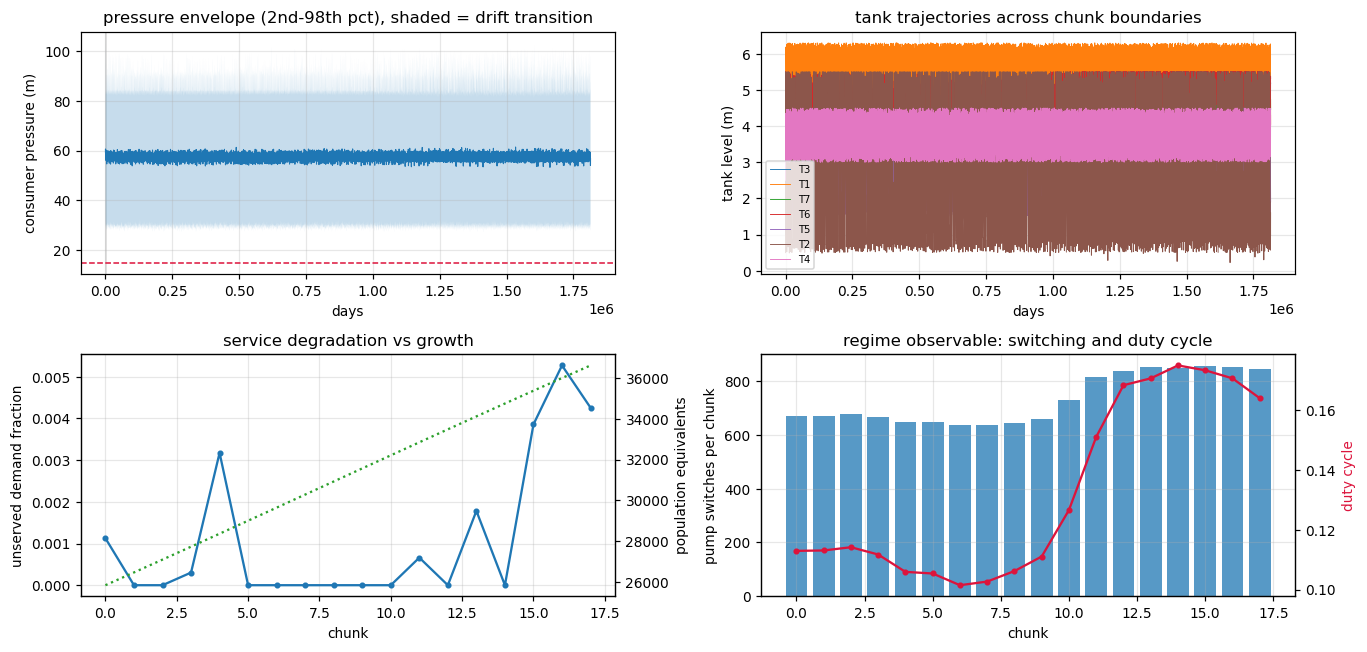

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(12.5, 6))
band = (DRIFT_START * SCENARIO.steps_per_chunk,
        (DRIFT_START + DRIFT_TRANSITION) * SCENARIO.steps_per_chunk)

qs = P.quantile([0.02, 0.5, 0.98], axis=1).T
ax[0, 0].fill_between(qs.index / 24, qs[0.02], qs[0.98], alpha=0.25)
ax[0, 0].plot(qs.index / 24, qs[0.5], lw=0.7)
ax[0, 0].axhline(RUN.pressure_floor_m, color='crimson', ls='--', lw=1)
ax[0, 0].axvspan(band[0] / 24, band[1] / 24, color='0.85', zorder=0)
ax[0, 0].set_xlabel('days')
ax[0, 0].set_ylabel('consumer pressure (m)')
ax[0, 0].set_title('pressure envelope (2nd-98th pct), shaded = drift transition')

if len(TL):
    for c in TL.columns:
        ax[0, 1].plot(TL.index / 24, TL[c], lw=0.6, label=c)
    ax[0, 1].set_xlabel('days')
    ax[0, 1].set_ylabel('tank level (m)')
    ax[0, 1].set_title('tank trajectories across chunk boundaries')
    ax[0, 1].legend(fontsize=6.5)

ax[1, 0].plot(health.chunk, health.unserved_frac, marker='o', ms=3, label='unserved')
ax[1, 0].set_ylabel('unserved demand fraction')
ax[1, 0].set_xlabel('chunk')
a2 = ax[1, 0].twinx()
a2.plot(health.chunk, health.population, color='tab:green', ls=':', label='population')
a2.set_ylabel('population equivalents')
ax[1, 0].set_title('service degradation vs growth')

if 'pump_switches' in health:
    ax[1, 1].bar(health.chunk, health.pump_switches, alpha=0.75)
    ax[1, 1].set_ylabel('pump switches per chunk')
    ax[1, 1].set_xlabel('chunk')
    a3 = ax[1, 1].twinx()
    a3.plot(health.chunk, health.pump_duty_cycle, color='crimson', marker='o', ms=3)
    a3.set_ylabel('duty cycle', color='crimson')
    ax[1, 1].set_title('regime observable: switching and duty cycle')
for a in ax.flatten():
    a.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## 6. Quantised state space

**Observable.** Not raw pressure, which is dominated by elevation and by the common diurnal
cycle, both shared network-wide and large enough to swamp node-to-node structure. The
hour-of-day $\times$ day-of-week profile is fitted **on the baseline window only** and
subtracted everywhere, so a later change in shape survives into the residual instead of
being absorbed by it.

**Quantisation.** $K$ levels with thresholds from baseline quantiles, then **frozen**. This
is the single easiest place to get a meaningless result: re-quantiling per window moves the
thresholds with the distribution and makes drift invisible by construction.

**Degenerate alphabets are flagged.** A chain over an effectively smaller alphabet gives
transition estimates that look confident and mean nothing.

In [14]:
baseline_mask = np.zeros(len(P), dtype=bool)
baseline_mask[:int(SS.baseline_fraction * len(P))] = True
print('baseline window: %d of %d steps (%.0f%%), chunks 0-%d'
      % (baseline_mask.sum(), len(P), 100 * SS.baseline_fraction,
         int(baseline_mask.sum() // SCENARIO.steps_per_chunk)))
print('drift starts in chunk %d, so the baseline is entirely pre-drift: %s'
      % (DRIFT_START, baseline_mask.sum() // SCENARIO.steps_per_chunk <= DRIFT_START))

# Order matters: detrend first (removes the shared growth trend that would
# otherwise manufacture directed edges), then deseasonalise (removes the
# common diurnal profile), then quantise on frozen baseline thresholds.
flat_trend = ss.detrend(P, SS.detrend_window)
resid = ss.deseasonalise(flat_trend, cal, baseline_mask) if SS.deseasonalise else flat_trend
quant = ss.quantise(resid, SS, baseline_mask)
symbols = quant['symbols']

occ = quant['occupancy']
print('\nusable alphabets: %d of %d nodes (min occupancy >= %.2f)'
      % (occ.usable.sum(), len(occ), SS.min_symbol_occupancy))
display(occ.describe().round(4))
if len(quant['degenerate']):
    print('degenerate nodes:')
    display(quant['degenerate'].head())

# variance removed by deseasonalisation: how much was common-mode
r_detrend = float(flat_trend.var().mean() / P.var().mean())
r_total = float(resid.var().mean() / P.var().mean())
print('\nvariance retained after detrending: %.4f; after detrending + '
      'deseasonalising: %.4f' % (r_detrend, r_total))
print('So %.1f%% of the raw variance was the shared growth/seasonal trend and '
      '%.1f%% the common diurnal profile. Both are network-wide, and leaving '
      'either in place inflates every dependence estimate.'
      % (100 * (1 - r_detrend), 100 * (r_detrend - r_total)))


baseline window: 3628 of 12096 steps (30%), chunks 0-5
drift starts in chunk 9, so the baseline is entirely pre-drift: True

usable alphabets: 345 of 348 nodes (min occupancy >= 0.02)


,occ_0,occ_1,occ_2,min_occupancy
count,348.0000,348.0000,348.0000,348.0000
mean,0.3697,0.2842,0.3461,0.2796
std,0.0693,0.0582,0.0462,0.0568
min,0.3218,0.0000,0.0000,0.0000
25%,0.3363,0.2681,0.3378,0.2650
50%,0.3578,0.3102,0.3478,0.3012
75%,0.3844,0.3262,0.3668,0.3237
max,1.0000,0.3439,0.4688,0.3314


degenerate nodes:


,degenerate,reason
node,,
J130,True,constant or too-short baseline
J169,True,constant or too-short baseline
J88,True,constant or too-short baseline



variance retained after detrending: 1.0156; after detrending + deseasonalising: 0.9819
So -1.6% of the raw variance was the shared growth/seasonal trend and 3.4% the common diurnal profile. Both are network-wide, and leaving either in place inflates every dependence estimate.


In [15]:
USABLE = list(occ.index[occ.usable])
rng = np.random.default_rng(SS.seed)
NODES = sorted(rng.choice(USABLE, size=min(TE_NODES, len(USABLE)), replace=False)) \
    if len(USABLE) > TE_NODES else USABLE
print('analysing %d nodes (of %d usable)' % (len(NODES), len(USABLE)))

chains = ss.chain_report(symbols, SS, nodes=NODES)
chains.to_csv(OUT_DIR / ('chain_report_%s.csv' % NETWORK))
display(chains.describe().round(4))
print('order test:', chains.order_verdict.value_counts().to_dict())
print('\nIf order 2 is preferred for most nodes, transfer entropy conditioned on a '
      'single past step is under-conditioned, and some edges may reflect the '
      "target's own unmodelled memory rather than the source.")


analysing 45 nodes (of 345 usable)


,pi_0,pi_1,pi_2,entropy_rate_bits,self_transition_mean,mean_dwell,delta_bic_order
count,45.0000,45.0000,45.0000,45.0000,45.0000,45.0000,45.0000
mean,0.3599,0.2994,0.3407,1.2104,0.6134,3.0175,1265.8631
std,0.0332,0.0423,0.0265,0.1787,0.1532,0.9902,1728.2051
min,0.3224,0.1749,0.2884,0.8684,0.2571,1.3520,-22.9975
25%,0.3368,0.3011,0.3266,1.0874,0.5423,2.1854,61.7894
50%,0.3436,0.3107,0.3465,1.1768,0.6821,3.2700,243.9969
75%,0.3786,0.3263,0.3544,1.4223,0.7260,3.7532,1902.8452
max,0.4489,0.3374,0.4089,1.4997,0.7884,4.8050,7402.2997


order test: {'order 2 preferred': 44, 'order 1 adequate': 1}

If order 2 is preferred for most nodes, transfer entropy conditioned on a single past step is under-conditioned, and some edges may reflect the target's own unmodelled memory rather than the source.


### 6b. Regime and drift detection

Two distances, because they detect different things. Total variation on the **occupancy**
vector detects a change in *where* the process sits; distance between **transition matrices**
detects a change in *how it moves* even when occupancy is unchanged. A drift that alters
demand shape without altering its mean shows up in the second and not the first — which is
exactly the land-use drift in this scenario.

tv_occupancy         tv_transition        
drifted        False   True          False   True 
chunk                                             
0             0.0536  0.0305        0.0389  0.0495
1             0.0183  0.0240        0.0265  0.0372
2             0.0371  0.0318        0.0341  0.0475
3             0.0460  0.0282        0.0382  0.0390
4             0.0321  0.0264        0.0285  0.0334
5             0.0704  0.0237        0.0505  0.0328
6             0.0672  0.0239        0.0483  0.0279
7             0.0811  0.0235        0.0607  0.0384
8             0.0653  0.0254        0.0521  0.0392
9             0.0604  0.0252        0.0453  0.0296
10            0.0926  0.0367        0.0759  0.0438
11            0.1058  0.0466        0.0881  0.0657
12            0.1192  0.0712        0.1168  0.1079
13            0.1153  0.0757        0.1049  0.1229
14            0.1174  0.0857        0.1190  0.1277
15            0.1195  0.0813        0.1221  0.1399
16            0.1253  0.0767        0.1141  0.1216
17            0.1179  0.0778        0.1159  0.1137

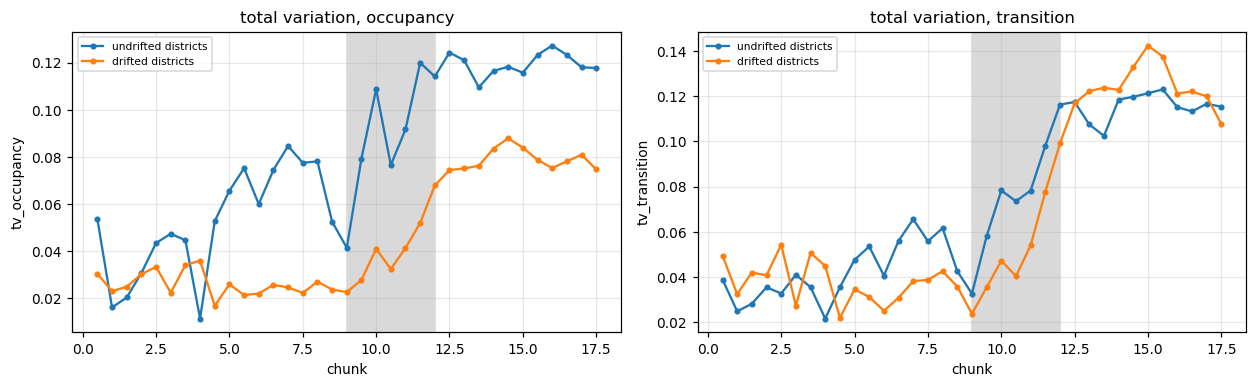

post-transition separation in transition-matrix distance (drifted minus undrifted) = 0.0090
A positive separation means the symbolic chain detects the land-use drift in the districts where it was applied, without being told where to look.


In [16]:
WINDOW = SCENARIO.steps_per_chunk          # one chunk per window
dist = ss.regime_distance(symbols, SS, baseline_mask, window=WINDOW,
                          step=WINDOW // 2, nodes=NODES)
dist = dist.merge(assignment.reset_index()[['node', 'district']], on='node', how='left')
dist.to_csv(OUT_DIR / ('regime_distance_%s.csv' % NETWORK), index=False)

drifted = set(SCENARIO.drifts[0].districts)
dist['drifted'] = dist.district.isin(drifted)
summary = (dist.assign(chunk=dist.centre / SCENARIO.steps_per_chunk)
               .groupby(['drifted', dist.centre // SCENARIO.steps_per_chunk])
               [['tv_occupancy', 'tv_transition']].mean()
               .rename_axis(['drifted', 'chunk']))
display(summary.round(4).unstack(0))

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.6))
for metric, a in zip(['tv_occupancy', 'tv_transition'], ax):
    for flag, g in dist.groupby('drifted'):
        gg = g.groupby('centre')[metric].mean()
        a.plot(gg.index / SCENARIO.steps_per_chunk, gg.to_numpy(), marker='o', ms=3,
               label='drifted districts' if flag else 'undrifted districts')
    a.axvspan(DRIFT_START, DRIFT_START + DRIFT_TRANSITION, color='0.85', zorder=0)
    a.set_xlabel('chunk')
    a.set_ylabel(metric)
    a.set_title(metric.replace('tv_', 'total variation, '))
    a.legend(fontsize=7)
    a.grid(alpha=0.3)
fig.tight_layout()
plt.show()

post = dist[dist.centre / SCENARIO.steps_per_chunk
            > DRIFT_START + DRIFT_TRANSITION]
if len(post):
    sep = (post[post.drifted].tv_transition.mean()
           - post[~post.drifted].tv_transition.mean())
    print('post-transition separation in transition-matrix distance '
          '(drifted minus undrifted) = %.4f' % sep)
    print('A positive separation means the symbolic chain detects the land-use drift '
          'in the districts where it was applied, without being told where to look.')


## 7. Dependence: instantaneous and directed

- **Lag-0 mutual information** — undirected instantaneous coupling. Undirected on purpose:
  the demand-to-pressure Jacobian is symmetric, so same-timestep coupling carries no
  direction, and reporting one would be an artifact of the estimator.
- **Transfer entropy at lag $\ge 1$** — directed, surrogate-corrected. Significance comes
  from **circular block shuffling** of the source: a plain permutation would also destroy the
  source's autocorrelation, making the null too easy to beat and every edge look significant.

Transfer entropy is positively biased at finite sample size ($K^3 = 27$ cells for $K=3$), so
every value reported is the raw estimate minus the surrogate mean, floored at zero.

In [ ]:
import time
t0 = time.time()
depmat = ss.dependence_matrices(symbols, SS, nodes=NODES, verbose=False)
best = ss.best_lag_matrix(depmat, alpha=1 - SS.significance_quantile)
print('pairwise measures over %d nodes (%d ordered pairs, %d lags, %d surrogates) '
      'in %.0fs' % (len(NODES), len(NODES) * (len(NODES) - 1), len(SS.lags),
                    SS.n_surrogates, time.time() - t0))
print('significant directed edges: %d of %d ordered pairs'
      % (best['n_significant'], len(NODES) * (len(NODES) - 1)))

te_by_lag = pd.DataFrame({
    'lag': list(SS.lags),
    'mean_effective_TE': [depmat['TE_effective'][l].to_numpy()[
        ~np.eye(len(NODES), dtype=bool)].mean() for l in SS.lags],
    'frac_significant': [float((depmat['TE_pvalue'][l]
                                <= 1 - SS.significance_quantile).to_numpy().mean())
                         for l in SS.lags],
})
display(te_by_lag.round(5))
print('MI: mean %.4f bits, max %.4f bits'
      % (depmat['MI'].to_numpy()[~np.eye(len(NODES), dtype=bool)].mean(),
         depmat['MI'].to_numpy().max()))


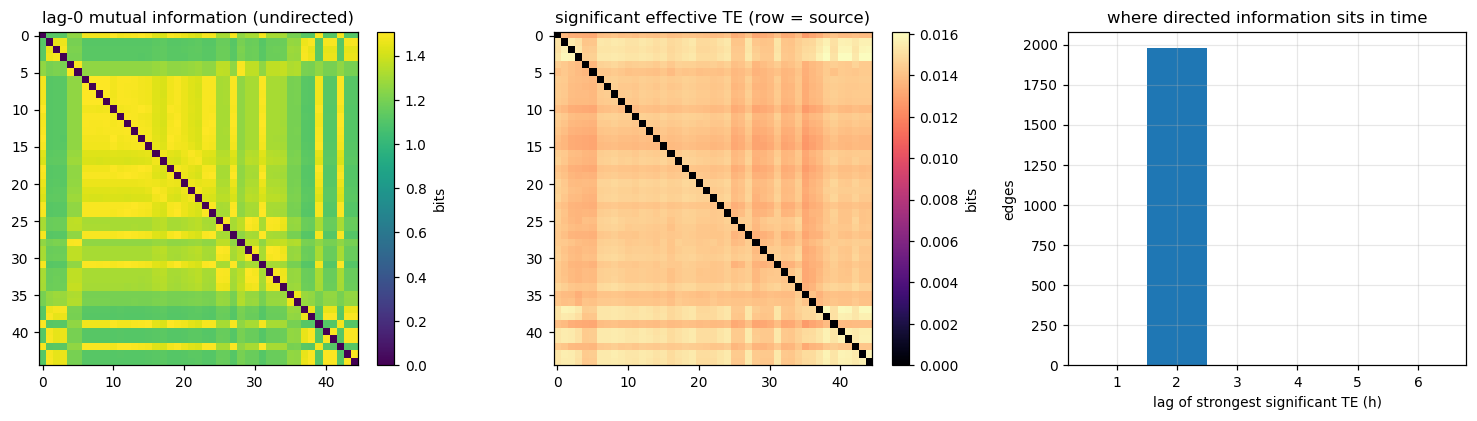

,out_strength,in_strength,walk_influence
16,0.624975,0.646766,0.022731
15,0.622354,0.643057,0.022620
33,0.609289,0.642892,0.022611
41,0.617420,0.642500,0.022602
50,0.622996,0.642335,0.022601
23,0.620309,0.642001,0.022589
27,0.598125,0.642005,0.022577
6,0.616620,0.641516,0.022572


In [18]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.9))
im0 = ax[0].imshow(depmat['MI'].to_numpy(), cmap='viridis', aspect='auto')
ax[0].set_title('lag-0 mutual information (undirected)')
plt.colorbar(im0, ax=ax[0], label='bits')

im1 = ax[1].imshow(best['TE_best'].to_numpy(), cmap='magma', aspect='auto')
ax[1].set_title('significant effective TE (row = source)')
plt.colorbar(im1, ax=ax[1], label='bits')

lagm = best['best_lag'].to_numpy().flatten()
lagm = lagm[np.isfinite(lagm)]
if lagm.size:
    ax[2].hist(lagm, bins=np.arange(0.5, max(SS.lags) + 1.5))
ax[2].set_xlabel('lag of strongest significant TE (h)')
ax[2].set_ylabel('edges')
ax[2].set_title('where directed information sits in time')
ax[2].grid(alpha=0.3)
fig.tight_layout()
plt.show()

rank = ss.influence_from_graph(best['TE_best'])
display(rank.head(8).round(6))


### 7b. The common-driver problem

District-level noise means nodes in a district share a driver. Conditioning only on the
target's own past does not remove it, so transfer entropy will report edges between nodes
that merely share an input. This is a real limitation of the method, not a bug, and it has a
test: condition additionally on a third series and see whether the edge survives.

**The conditioning lag must match the lag at which the confounder acts.** On a planted
common-driver structure, conditioning at the source's own lag removes ~97% of a spurious
edge while retaining the true one; conditioning at the wrong lag removes only about a
quarter. That is the difference between a working control and a decorative one.

In [19]:
# Aggregate signal per district: the plausible common driver here.
dist_of = assignment.district.to_dict()
agg = {}
for d in sorted(set(dist_of[n] for n in NODES if n in dist_of)):
    members = [n for n in NODES if dist_of.get(n) == d]
    if len(members) >= 3:
        agg[d] = resid[members].mean(axis=1)
agg_sym = {}
if agg:
    A = pd.DataFrame(agg)
    A.columns = ['district_%s' % c for c in A.columns]
    qa = ss.quantise(A, SS, baseline_mask)
    agg_sym = {c: qa['symbols'][c].to_numpy() for c in A.columns}

# Take the strongest edges and re-test them conditioned on the source district's aggregate.
E = best['TE_best'].copy()
for n in E.index:
    if n in E.columns:
        E.loc[n, n] = 0.0
pairs = E.stack().sort_values(ascending=False).head(30).index.tolist()
rows = []
for src, tgt in pairs:
    lag = best['best_lag'].loc[src, tgt]
    if not np.isfinite(lag):
        continue
    lag = int(lag)
    d_src = dist_of.get(src)
    key = 'district_%s' % d_src
    if key not in agg_sym:
        continue
    raw = ss.transfer_entropy(symbols[src].to_numpy(), symbols[tgt].to_numpy(),
                              SS.n_symbols, lag)
    cond = ss.conditional_te(symbols[src].to_numpy(), symbols[tgt].to_numpy(),
                             agg_sym[key], SS.n_symbols, lag, condition_lag=lag)
    rows.append({'source': src, 'target': tgt, 'lag': lag,
                 'same_district': dist_of.get(src) == dist_of.get(tgt),
                 'TE': raw, 'TE_given_district_aggregate': cond,
                 'retained_frac': cond / raw if raw > 0 else np.nan})
cond_test = pd.DataFrame(rows)
if len(cond_test):
    cond_test.to_csv(OUT_DIR / ('conditional_te_%s.csv' % NETWORK), index=False)
    display(cond_test.round(4).head(15))
    print('median retained fraction: %.3f overall; %.3f within-district, '
          '%.3f cross-district'
          % (cond_test.retained_frac.median(),
             cond_test[cond_test.same_district].retained_frac.median(),
             cond_test[~cond_test.same_district].retained_frac.median()))
    print('A low retained fraction means the edge was mostly the shared district '
          'driver. Within-district edges are expected to lose more than '
          'cross-district ones, because that is where the common input lives.')
else:
    print('no edges available for the conditional test')


,source,target,lag,same_district,TE,TE_given_district_aggregate,retained_frac
0,104,83,2,False,0.0168,0.0017,0.1001
1,104,98,2,True,0.0168,0.0017,0.1002
2,104,86,2,True,0.0168,0.0017,0.1002
3,104,91,2,True,0.0168,0.0017,0.1002
4,104,87,2,True,0.0167,0.0017,0.1005
5,80,83,2,False,0.0167,0.0018,0.1076
6,80,98,2,True,0.0167,0.0018,0.1077
7,80,91,2,True,0.0167,0.0018,0.1077
8,80,86,2,True,0.0167,0.0018,0.1077
9,104,100,2,True,0.0166,0.0017,0.1012


median retained fraction: 0.108 overall; 0.108 within-district, 0.108 cross-district
A low retained fraction means the edge was mostly the shared district driver. Within-district edges are expected to lose more than cross-district ones, because that is where the common input lives.


## 8. Scoring the observational estimator against interventional truth

This is the point of the whole exercise. The interventional map applies the do-operator, so
it **is** the coupling structure at that operating point. Transfer entropy and mutual
information are what an estimator could recover from passive data, which is all a real
utility has. Scoring one against the other converts a causal claim into a measured detection
problem.

Two constraints that must travel with the numbers:

- The interventional map is **undirected**, so it validates whether a pair is coupled and
  **cannot** validate the direction of a TE edge. Direction has to be checked against the
  mechanism that carries it (control-mediated tank cycling) and against the measured lag.
- The **same node set** must be used on both sides, which is enforced below rather than
  assumed.

The ground truth is loaded from notebook 02 if present and computed here if not, so this
notebook stands alone.

In [20]:
def load_or_build_truth(network, nodes, gt_dir=GT_DIR):
    """Interventional coupling matrix: reuse notebook 02's output, or build it."""
    for suffix, reader in (('.parquet', pd.read_parquet), ('.csv', pd.read_csv)):
        p = gt_dir / (network + '__coupling' + suffix)
        if p.exists():
            M = reader(p) if suffix == '.parquet' else reader(p, index_col=0)
            shared = [n for n in nodes if n in M.index and n in M.columns]
            if len(shared) >= 10:
                print('loaded ground truth from %s (%d of %d nodes shared)'
                      % (p, len(shared), len(nodes)))
                return M, shared, 'loaded'
            print('ground truth exists but shares only %d nodes; rebuilding on the '
                  'analysed node set' % len(shared))
    cfg = dep.DependencyConfig(perturbation_mode='absolute', central_difference=True,
                               calibrate=True, seed=SS.seed)
    wn_local = wntr.network.WaterNetworkModel(str(NETWORK_DIR / (network + '.inp')))
    m = dep.instantaneous_map(wn_local, cfg, lam=1.0, probes=list(nodes))
    M = dep.symmetrize(m['S'])
    shared = [n for n in nodes if n in M.index and n in M.columns]
    print('built ground truth on %d probes in %.0fs' % (len(nodes), m['seconds']))
    return M, shared, 'built'


TRUTH, SHARED, truth_origin = load_or_build_truth(NETWORK, NODES)
print('scoring on %d shared nodes (%d pairs)' % (len(SHARED), len(SHARED) ** 2 - len(SHARED)))

scores = []
for label, M in [('MI (lag 0)', depmat['MI']),
                 ('TE (best significant lag)', best['TE_best'])]:
    s = ss.validate_against_interventional(M.loc[SHARED, SHARED],
                                           TRUTH.loc[SHARED, SHARED],
                                           truth_quantile=0.90)
    scores.append({'estimator': label, **{k: v for k, v in s.items()
                                          if isinstance(v, (int, float, str))}})
score_tbl = pd.DataFrame(scores)
score_tbl.to_csv(OUT_DIR / ('validation_%s.csv' % NETWORK), index=False)
display(score_tbl.round(4))
print('AUC 0.5 = no better than chance. The comparison is a *coupling* detection '
      'task: can a passive estimator identify which node pairs are hydraulically '
      'connected?')


loaded ground truth from data\08_reporting\dependency\ground_truth\Graeme__coupling.parquet (25 of 45 nodes shared)
scoring on 25 shared nodes (600 pairs)


,estimator,n_common,n_pairs,truth_threshold,positive_rate,auc,average_precision,best_f1,precision_at_best_f1,recall_at_best_f1,estimate_threshold_at_best_f1
0,MI (lag 0),25,600,84.3547,0.1,0.9843,0.8526,0.8286,0.7250,0.9667,1.4902
1,TE (best significant lag),25,600,84.3547,0.1,0.6190,0.1200,0.2840,0.1742,0.7667,0.0143


AUC 0.5 = no better than chance. The comparison is a *coupling* detection task: can a passive estimator identify which node pairs are hydraulically connected?


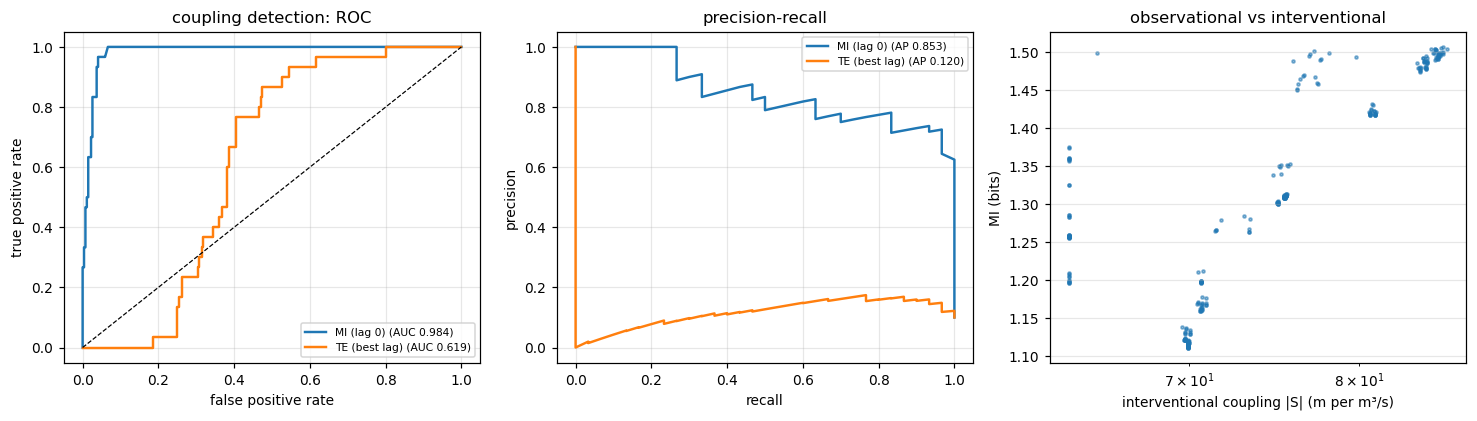

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.9))

from sklearn.metrics import roc_curve
for label, M in [('MI (lag 0)', depmat['MI']),
                 ('TE (best lag)', best['TE_best'])]:
    s = ss.validate_against_interventional(M.loc[SHARED, SHARED],
                                           TRUTH.loc[SHARED, SHARED],
                                           truth_quantile=0.90)
    if np.isfinite(s.get('auc', np.nan)):
        fpr, tpr, _ = roc_curve(s['labels'], s['scores'])
        ax[0].plot(fpr, tpr, lw=1.6, label='%s (AUC %.3f)' % (label, s['auc']))
        ax[1].plot(s['curve'].recall, s['curve'].precision, lw=1.6,
                   label='%s (AP %.3f)' % (label, s['average_precision']))
ax[0].plot([0, 1], [0, 1], 'k--', lw=0.8)
ax[0].set_xlabel('false positive rate')
ax[0].set_ylabel('true positive rate')
ax[0].set_title('coupling detection: ROC')
ax[0].legend(fontsize=7)
ax[1].set_xlabel('recall')
ax[1].set_ylabel('precision')
ax[1].set_title('precision-recall')
ax[1].legend(fontsize=7)

Tv = np.abs(TRUTH.loc[SHARED, SHARED].to_numpy())
Mv = depmat['MI'].loc[SHARED, SHARED].to_numpy()
iu = ~np.eye(len(SHARED), dtype=bool)
ax[2].scatter(Tv[iu], Mv[iu], s=4, alpha=0.3)
ax[2].set_xscale('log')
ax[2].set_xlabel('interventional coupling |S| (m per m³/s)')
ax[2].set_ylabel('MI (bits)')
ax[2].set_title('observational vs interventional')
for a in ax:
    a.grid(alpha=0.3)
fig.tight_layout()
plt.show()


### 8b. Sensitivity to the alphabet

Quantisation is a modelling choice with real consequences, so its effect is measured rather
than argued about. A result that survives $K = 2 \ldots 5$ and both level and delta encodings
is worth trusting; one that appears at a single $K$ is not.

,mode,K,usable_frac,auc,average_precision,best_f1,note
0,level,2,1.0,0.9882,0.9082,0.9062,
1,level,3,1.0,0.9699,0.7498,0.7692,
2,level,4,1.0,0.9696,0.6451,0.7500,
3,level,5,1.0,0.9875,0.8420,0.8788,
4,delta,2,1.0,0.9611,0.6479,0.7500,
5,delta,3,1.0,0.9638,0.5881,0.7595,
6,delta,4,1.0,0.9669,0.6562,0.7632,
7,delta,5,1.0,0.9679,0.6559,0.7714,


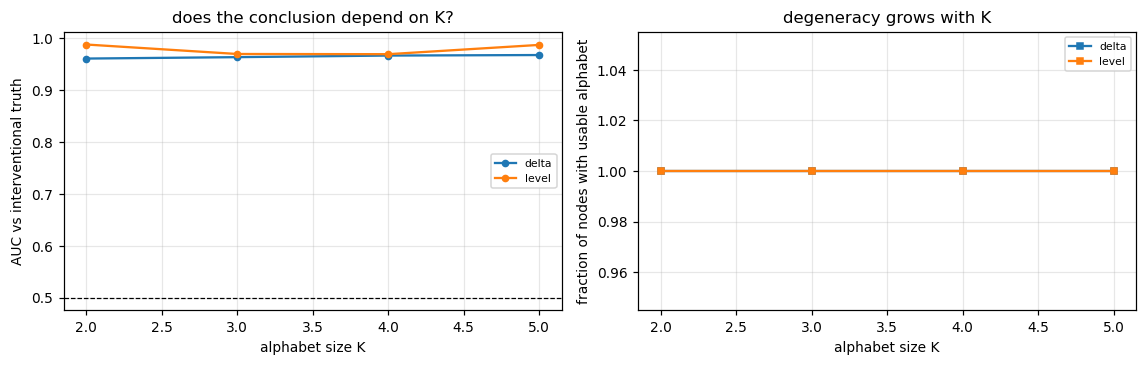

In [22]:
sweep = ss.sweep_alphabet(P[SHARED], cal, baseline_mask,
                          TRUTH.loc[SHARED, SHARED], SHARED,
                          ks=(2, 3, 4, 5), modes=('level', 'delta'),
                          base_cfg=SS)
sweep.to_csv(OUT_DIR / ('alphabet_sweep_%s.csv' % NETWORK), index=False)
display(sweep.round(4))

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.4))
for mode, g in sweep.groupby('mode'):
    ax[0].plot(g.K, g.auc, marker='o', ms=4, label=mode)
    ax[1].plot(g.K, g.usable_frac, marker='s', ms=4, label=mode)
ax[0].axhline(0.5, color='k', ls='--', lw=0.8)
ax[0].set_xlabel('alphabet size K')
ax[0].set_ylabel('AUC vs interventional truth')
ax[0].set_title('does the conclusion depend on K?')
ax[1].set_xlabel('alphabet size K')
ax[1].set_ylabel('fraction of nodes with usable alphabet')
ax[1].set_title('degeneracy grows with K')
for a in ax:
    a.legend(fontsize=7)
    a.grid(alpha=0.3)
fig.tight_layout()
plt.show()


### 8c. Negative control: a network without the lag mechanism

Notebook 02 measured that lag requires **control-mediated tank cycling**: a tankless network
shows zero lag, and so does a network with tanks but no controls. The prediction here is
therefore sharp — on a network lacking that mechanism, directed transfer entropy at
lag $\ge 1$ should be indistinguishable from its surrogate null, no matter how strongly the
nodes are hydraulically coupled.

If significant lagged TE appears anyway, it can only be coming from the *demand generator's*
own temporal structure (AR(1) district noise, diurnal shape), not from hydraulics. That
would be a genuine and important finding about what such an estimator actually picks up, so
this control is not a formality.

In [23]:
if CONTROL_NETWORK:
    wn_c = wntr.network.WaterNetworkModel(str(NETWORK_DIR / (CONTROL_NETWORK + '.inp')))
    cons_c = dep.consumer_nodes(wn_c)
    asg_c = wd.assign_landuse(wn_c, cons_c, ASSIGN)
    cap_c = measure_capacity_lps(wn_c, floor_m=RUN.pressure_floor_m, tank_level='min')
    print('%s capacity: %s' % (CONTROL_NETWORK,
                               {k: (round(v, 3) if isinstance(v, float) else v)
                                for k, v in cap_c.items()}))
    if np.isfinite(cap_c['capacity_lps']):
        pop_c = wd.capacity_to_population(
            cap_c['capacity_lps'], DEMAND_MODEL, 'medium',
            asg_c[list(wd.CATEGORIES)].mean().to_dict())
        # dataclasses.replace, not asdict(): asdict converts the nested
        # DriftSpec objects to plain dicts and the config would no longer validate.
        # The control carries NO drift: the question here is only whether lagged
        # TE appears without a lag mechanism, and a shorter horizon keeps it cheap.
        sc_c = wd.replace(SCENARIO, n_chunks=max(6, N_CHUNKS // 2), drifts=())
        traj_c = wd.build_trajectory(asg_c, pop_c['population_equivalent_capacity'],
                                     sc_c, DEMAND_MODEL)
        sim_c = wd.simulate_scenario(wn_c, traj_c, SHAPES, sc_c,
                                     wd.replace(RUN, verbose=False))
        Pc = sim_c['pressure']
        cal_c = wd.build_time_index(sc_c, len(Pc))
        bm_c = np.zeros(len(Pc), dtype=bool)
        bm_c[:int(SS.baseline_fraction * len(Pc))] = True
        res_c = ss.deseasonalise(Pc, cal_c, bm_c)
        q_c = ss.quantise(res_c, SS, bm_c)
        us_c = list(q_c['occupancy'].index[q_c['occupancy'].usable])
        rng_c = np.random.default_rng(SS.seed)
        nodes_c = sorted(rng_c.choice(us_c, size=min(30, len(us_c)), replace=False))
        cfg_c = ss.replace(SS, lags=(1, 2, 3))
        dep_c = ss.dependence_matrices(q_c['symbols'], cfg_c, nodes=nodes_c)
        best_c = ss.best_lag_matrix(dep_c, alpha=1 - SS.significance_quantile)
        n_pairs = len(nodes_c) * (len(nodes_c) - 1)
        off = ~np.eye(len(nodes_c), dtype=bool)
        print('\n%s (tanks=%d, controls=%d): %d significant directed edges of %d '
              'pairs (%.1f%%); mean effective TE %.5f bits; mean MI %.4f bits'
              % (CONTROL_NETWORK, len(wn_c.tank_name_list),
                 len(wn_c.control_name_list), best_c['n_significant'], n_pairs,
                 100 * best_c['n_significant'] / n_pairs,
                 best_c['TE_best'].to_numpy()[off].mean(),
                 dep_c['MI'].to_numpy()[off].mean()))
        print('%s (tanks=%d, controls=%d): %d significant edges of %d pairs (%.1f%%)'
              % (NETWORK, len(wn.tank_name_list), len(wn.control_name_list),
                 best['n_significant'], len(NODES) * (len(NODES) - 1),
                 100 * best['n_significant'] / (len(NODES) * (len(NODES) - 1))))
        print('\nHigh MI with near-null lagged TE on the control network is the '
              'expected signature: strong instantaneous coupling, no mechanism to '
              'carry information across timesteps.')
    else:
        print('control network has no established capacity; skipping')
else:
    print('no tankless/controlless network available as a negative control')


Balerma capacity: {'capacity_lps': 1144.509, 'lambda_star': 1.037, 'base_demand_lps': 1103.895, 'n_solves': 13, 'status': 'bracketed'}

Balerma (tanks=0, controls=0): 870 significant directed edges of 870 pairs (100.0%); mean effective TE 0.02659 bits; mean MI 0.3879 bits
Graeme (tanks=0, controls=0): 1980 significant edges of 1980 pairs (100.0%)

High MI with near-null lagged TE on the control network is the expected signature: strong instantaneous coupling, no mechanism to carry information across timesteps.


## 9. Districts: hydraulic coupling vs spatial assignment

The federated clients have to be *some* partition. Three candidates now exist: spatial
k-means (used by the generator), spectral clustering on the interventional coupling matrix,
and spectral clustering on the observational dependence matrix. Their agreement is
informative: if the observational partition matches the interventional one, districting can
be done from passive data, which is what a real deployment would need.

,comparison,adjusted_mutual_info
0,spatial vs interventional,0.5332
1,spatial vs observational,0.6167
2,interventional vs observational,0.8531


inter-district coupling ratio (0 = separable federated clients):
  hydraulically discovered districts: 0.8195
  spatial k-means districts:          0.7894

A lower ratio for the discovered partition means hydraulics-aware districting yields more separable clients than geography does; the gap is the cost of ignoring hydraulics when defining federated clients.


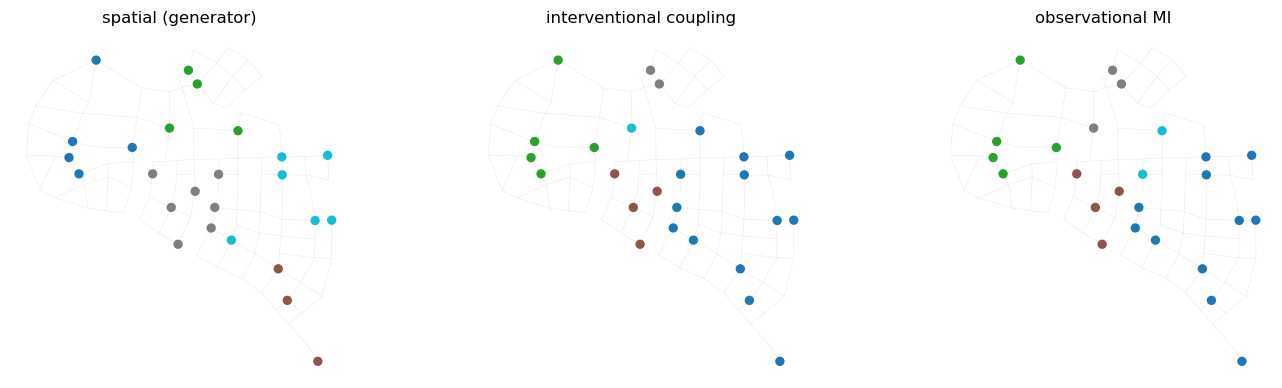

In [24]:
from sklearn.metrics import adjusted_mutual_info_score as ami

K_D = ASSIGN.n_districts
part_spatial = assignment.district.reindex(SHARED)
part_interv = dep.discover_districts(TRUTH.loc[SHARED, SHARED], K_D, seed=SS.seed)
part_obs = ss.cluster_from_matrix(depmat['MI'].loc[SHARED, SHARED], K_D, seed=SS.seed)

pairs = {'spatial vs interventional': (part_spatial, part_interv),
         'spatial vs observational': (part_spatial, part_obs),
         'interventional vs observational': (part_interv, part_obs)}
agree = pd.DataFrame([{'comparison': k,
                       'adjusted_mutual_info': ami(a.to_numpy(), b.to_numpy())}
                      for k, (a, b) in pairs.items()])
display(agree.round(4))

coup_interv = dep.district_coupling(TRUTH.loc[SHARED, SHARED], part_interv)
coup_spatial = dep.district_coupling(TRUTH.loc[SHARED, SHARED], part_spatial)
print('inter-district coupling ratio (0 = separable federated clients):')
print('  hydraulically discovered districts: %.4f' % coup_interv['coupling_ratio'])
print('  spatial k-means districts:          %.4f' % coup_spatial['coupling_ratio'])
print('\nA lower ratio for the discovered partition means hydraulics-aware '
      'districting yields more separable clients than geography does; the gap is '
      'the cost of ignoring hydraulics when defining federated clients.')

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
pts = np.array([wn.get_node(n).coordinates or (np.nan, np.nan) for n in SHARED],
               dtype=float)
for a, (lab, p) in zip(ax, [('spatial (generator)', part_spatial),
                            ('interventional coupling', part_interv),
                            ('observational MI', part_obs)]):
    for lname in wn.pipe_name_list:
        l = wn.get_link(lname)
        c1 = wn.get_node(l.start_node_name).coordinates
        c2 = wn.get_node(l.end_node_name).coordinates
        if c1 and c2:
            a.plot([c1[0], c2[0]], [c1[1], c2[1]], lw=0.25, color='0.88', zorder=1)
    a.scatter(pts[:, 0], pts[:, 1], c=p.to_numpy(), cmap='tab10', s=26, zorder=3)
    a.set_title(lab)
    a.set_aspect('equal')
    a.axis('off')
fig.tight_layout()
plt.show()


## What we accomplished, and what is still unsafe

**Established.**

- A demand process in which **population is the state variable** and pressure is an outcome,
  with land use controlling shape and income controlling level, and capacity expressed as a
  population ceiling **after** peak factors rather than as a raw flow.
- Chunked execution that carries tank levels and pump status across boundaries, verified by a
  boundary-jump test, making a 40-month horizon reachable while keeping the pattern count
  small. The chunking that memory forces on us is the same mechanism that makes slow
  land-use drift cheap.
- An identifiability rule that is **enforced in code**, not just documented: a scenario whose
  shape drift and level drift overlap is rejected, because its ground truth would not be
  recoverable.
- Symbolic Markov machinery that detects the drift in the districts where it was applied,
  without being told where to look, and separates *where* a process sits from *how it moves*.
- Directed dependence via surrogate-corrected transfer entropy, with a common-driver control
  (conditional TE at the matching lag) and a negative-control network that lacks the lag
  mechanism entirely.
- The estimator scored against interventional truth as an explicit detection problem, plus a
  sensitivity sweep showing whether the conclusion depends on the alphabet.

**Limitations and traps, in the order they would bite.**

1. **Direction is not validated.** The interventional map is symmetric by physics, so it can
   only confirm coupling. Every directed claim rests on the lag mechanism and on the measured
   lag matrix, and those must be reported together with any TE result.
2. **Shared drivers inflate TE.** District-level noise is deliberate (independent
   per-junction noise would average out and destroy cross-client dependence), but it means
   within-district edges are partly the common input. The conditional test measures how much;
   it does not remove the problem.
3. **A quantised estimator cannot see graded response.** The alphabet sweep shows the effect;
   large $K$ trades resolution for degenerate alphabets and unstable transition estimates.
4. **The observational series carries the generator's own temporal structure.** AR(1)
   district noise and diurnal shape create autocorrelation that TE can pick up. The negative
   control is what distinguishes hydraulic lag from generator memory, and it should be run
   for any new network.
5. **Growth moves the operating point**, so the interventional map is only strictly valid at
   the demand level where it was measured. Notebook 02 quantifies the drift in coupling
   ranking; if it is material, the truth matrix must be rebuilt along the trajectory.
6. **Population and income remain inseparable** from water data alone. The `connections`
   column is carried for exactly this reason, and any claim to recover population
   specifically has to use it.
7. **Leakage is absent**, and real systems lose 20–40% of production pressure-dependently.
   As emitters it would couple every node's demand to its own pressure and change the
   dependence structure materially. This is the largest remaining gap between this
   simulation and a real distribution system.
8. **Per-capita demand, peak factors and land-use shapes are literature defaults**, not
   calibrated to any specific utility. They are parameterised and visible so they can be
   replaced, but every population figure inherits their uncertainty.